In [1]:
import math
import random
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# ==========================================================
# 1. KONFIGURASI SISTEM & GENERASI DATA
# ==========================================================
random.seed(42)
np.random.seed(42)

NUM_HOUSES = 100
GRID_SIZE = 30 
NUM_TPS = 3
NUM_GARTS = 6
NUM_TRUCKS = 3

TIME_GAR_START = 6 * 60  
TIME_GAR_END = 15 * 60    
TIME_TRK_START = 8 * 60  
TIME_TRK_END = 17 * 60    

DEPOT_X, DEPOT_Y = 15, 15 # Koordinat Kantor Kades

class Entity:
    def __init__(self, id_ent, x, y):
        self.id = id_ent
        self.x = x
        self.y = y

class House(Entity):
    def __init__(self, id_ent, x, y):
        super().__init__(id_ent, x, y)
        self.waste = random.uniform(0.1, 7.0)

class TPS(Entity):
    def __init__(self, id_ent, x, y):
        super().__init__(id_ent, x, y)
        self.cap = random.uniform(400, 500)
        self.load = 0

class Vehicle(Entity):
    def __init__(self, id_ent, vtype, cap, start_t, end_t, speed_min_per_dist, load_min_per_kg):
        super().__init__(id_ent, DEPOT_X, DEPOT_Y) # Mulai dari Kantor Kades
        self.vtype = vtype
        self.cap = cap
        self.load = 0
        self.t = start_t
        self.start_t = start_t
        self.end_t = end_t
        self.speed = speed_min_per_dist
        self.load_time = load_min_per_kg
        self.dist_traveled = 0
        self.log = []

def get_dist(p1, p2):
    return math.hypot(p1.x - p2.x, p1.y - p2.y)

# Inisialisasi Objek
houses = [House(f"H{i+1}", random.uniform(0, GRID_SIZE), random.uniform(0, GRID_SIZE)) for i in range(NUM_HOUSES)]
tps_coords = [(5, 5), (GRID_SIZE-5, GRID_SIZE-5), (GRID_SIZE/2, GRID_SIZE-5)]
tps_list = [TPS(f"TPS{i+1}", tps_coords[i][0], tps_coords[i][1]) for i in range(NUM_TPS)]

carts = [Vehicle(f"Gerobak-{i+1}", "Gerobak", 15, TIME_GAR_START, TIME_GAR_END, 3.0, 2.0) for i in range(NUM_GARTS)]
trucks = [Vehicle(f"Truk-{i+1}", "Truk", 200, TIME_TRK_START, TIME_TRK_END, 3.0/5.0, 2.0/10.0) for i in range(NUM_TRUCKS)]
all_vehicles = carts + trucks

Membuat peta interkoneksi...


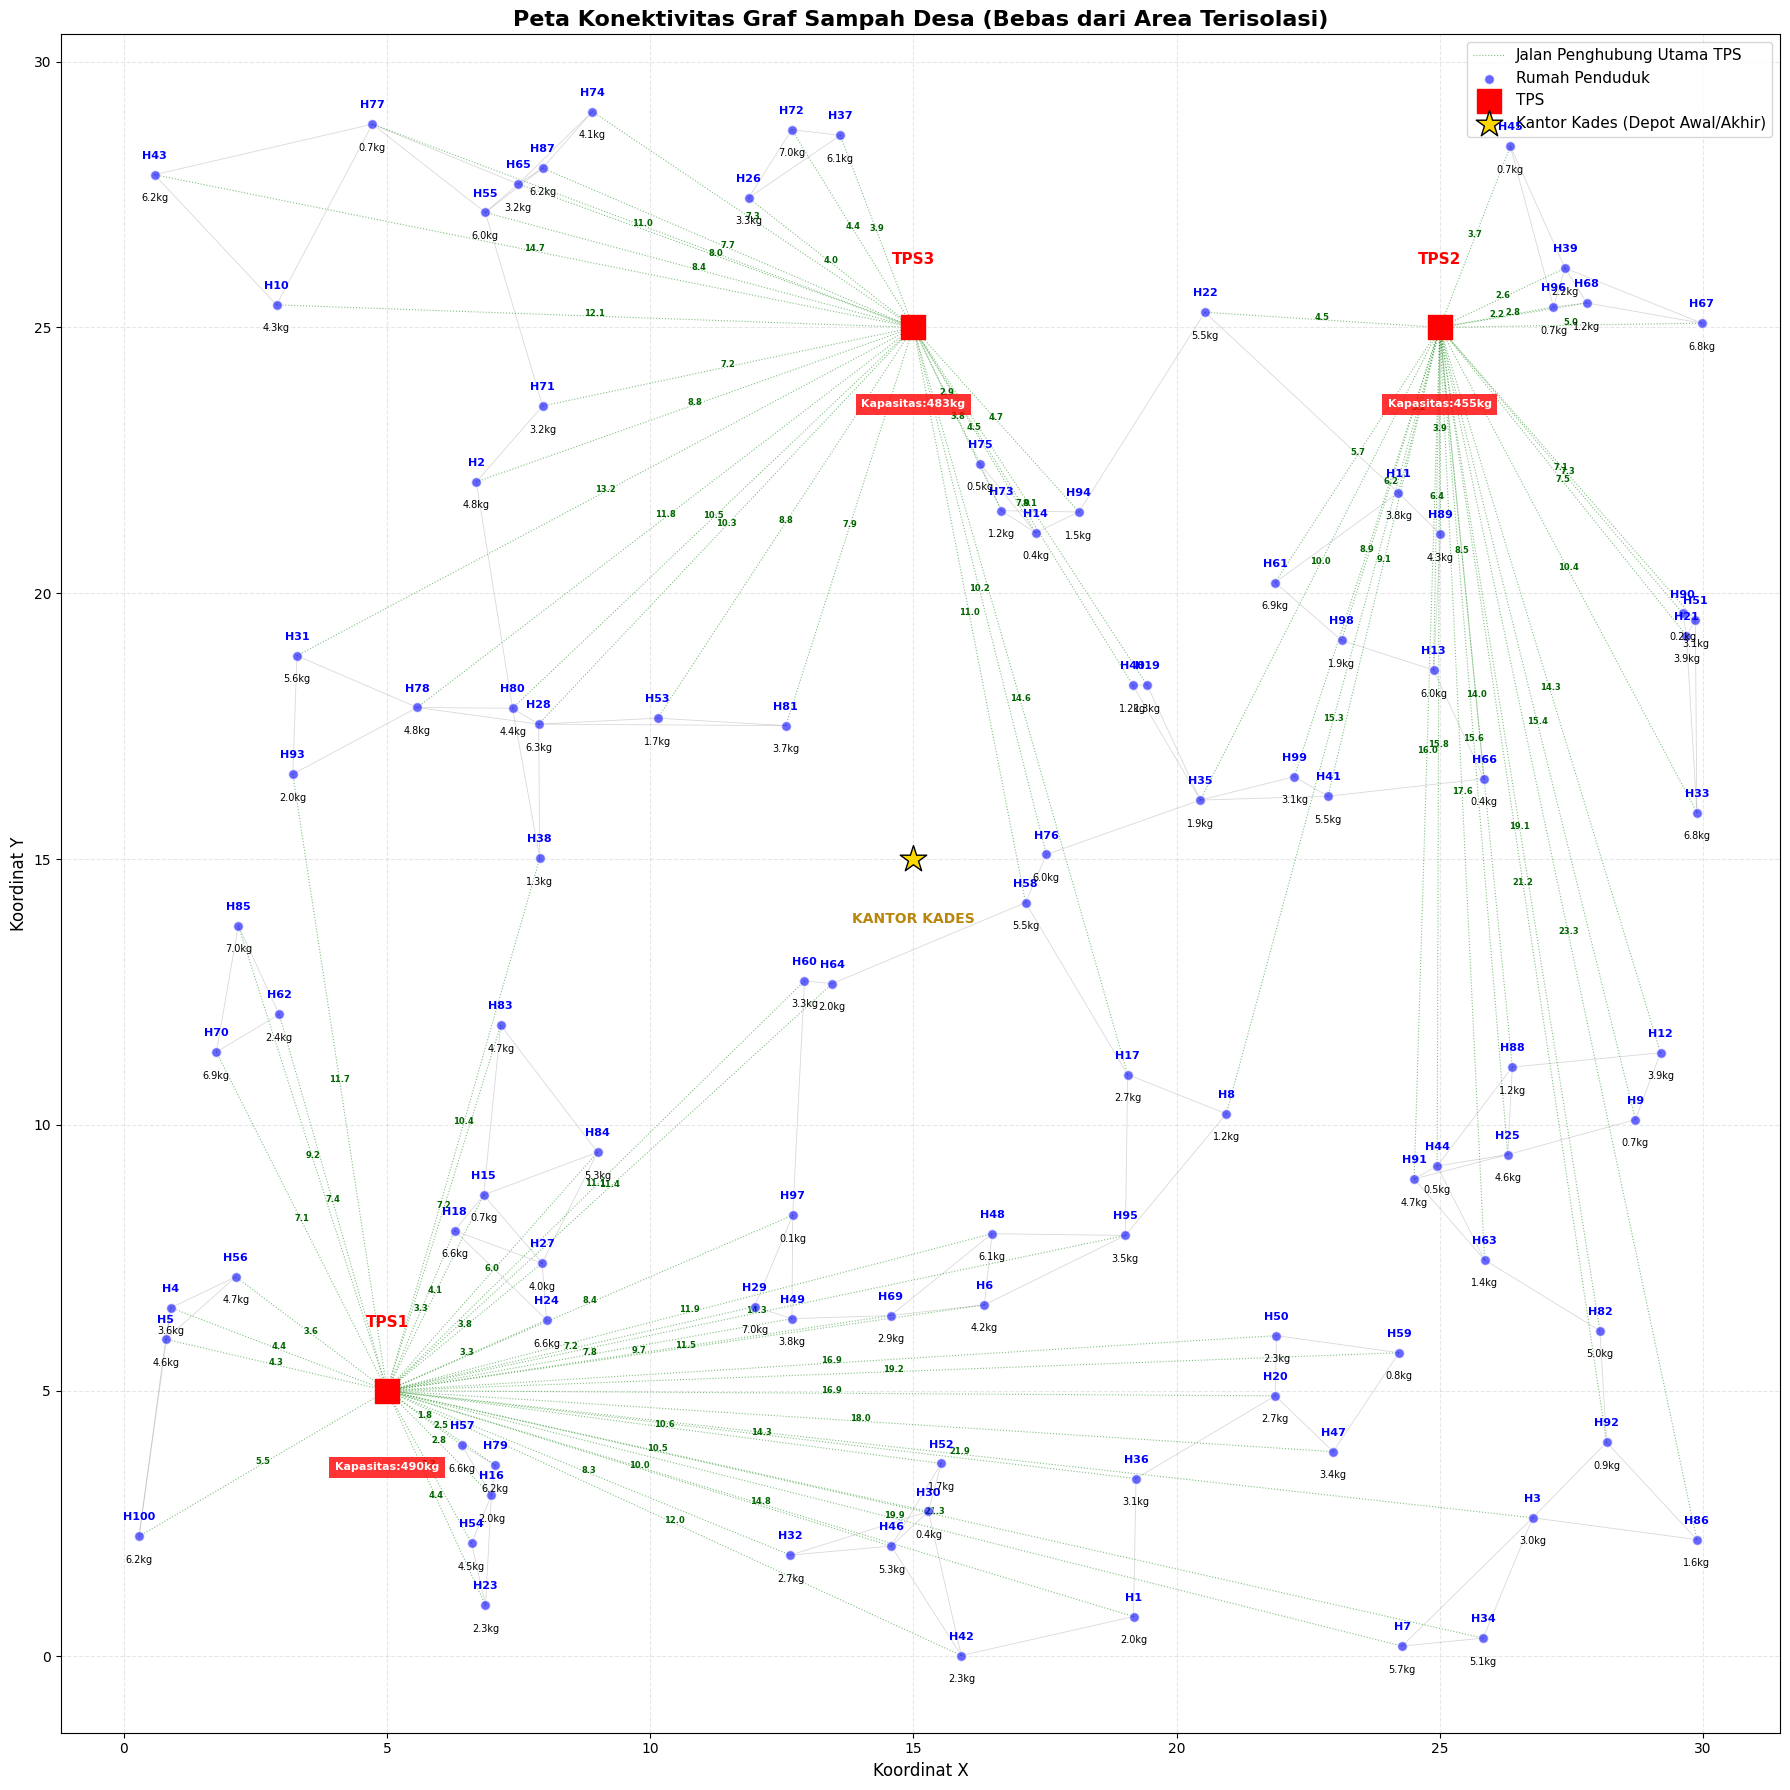

In [3]:
# ==========================================================
# 2. SELEKSI JALAN DAN VISUALISASI TANPA AREA TERISOLASI
# ==========================================================
def plot_village_map(houses, tps_list):
    plt.figure(figsize=(18, 18))
    seen_edges = set()
    
    # Hubungkan setiap rumah ke 2 tetangga terdekatnya
    for start_node in houses:
        distances = []
        for end_node in houses:
            if start_node.id == end_node.id: continue
            distances.append((get_dist(start_node, end_node), end_node))
        distances.sort(key=lambda x: x[0])
        
        for i in range(min(2, len(distances))):
            d, end_node = distances[i]
            pair = tuple(sorted((start_node.id, end_node.id)))
            if pair not in seen_edges:
                plt.plot([start_node.x, end_node.x], [start_node.y, end_node.y], color='gray', linestyle='-', linewidth=0.6, alpha=0.3)
                seen_edges.add(pair)
                
    # JALAN KRUSIAL: Hubungkan setiap rumah ke TPS terdekat untuk memutus isolasi graf
    for h in houses:
        closest_tps = min(tps_list, key=lambda t: get_dist(h, t))
        d = get_dist(h, closest_tps)
        pair = tuple(sorted((h.id, closest_tps.id)))
        if pair not in seen_edges:
            plt.plot([h.x, closest_tps.x], [h.y, closest_tps.y], color='green', linestyle=':', linewidth=0.8, alpha=0.5, label='Jalan Penghubung Utama TPS' if 'Jalan Penghubung Utama TPS' not in plt.gca().get_legend_handles_labels()[1] else "")
            mid_x, mid_y = (h.x + closest_tps.x)/2, (h.y + closest_tps.y)/2
            plt.text(mid_x, mid_y, f"{d:.1f}", color='darkgreen', fontsize=6, fontweight='bold', ha='center')
            seen_edges.add(pair)

    # Plot Rumah Penduduk
    plt.scatter([h.x for h in houses], [h.y for h in houses], c='blue', s=50, label='Rumah Penduduk', alpha=0.6, edgecolors='white', zorder=5)
    for h in houses:
        plt.text(h.x, h.y + 0.3, f"{h.id}", fontsize=8, color='blue', ha='center', fontweight='bold', zorder=6)
        plt.text(h.x, h.y - 0.5, f"{h.waste:.1f}kg", fontsize=7, color='black', ha='center', zorder=6)

    # Plot TPS
    plt.scatter([t.x for t in tps_list], [t.y for t in tps_list], c='red', marker='s', s=300, label='TPS', zorder=10)
    for t in tps_list:
        plt.text(t.x, t.y + 1.2, f"{t.id}", fontsize=11, color='red', ha='center', fontweight='bold', zorder=11)
        plt.text(t.x, t.y - 1.5, f"Kapasitas:{t.cap:.0f}kg", fontsize=8, color='white', ha='center', fontweight='bold', bbox=dict(facecolor='red', alpha=0.8, edgecolor='none'))

    # Plot Kantor Kades (Depot)
    plt.scatter(DEPOT_X, DEPOT_Y, c='gold', marker='*', s=400, label='Kantor Kades (Depot Awal/Akhir)', zorder=15, edgecolors='black')
    plt.text(DEPOT_X, DEPOT_Y - 1.2, "KANTOR KADES", fontsize=10, color='darkgoldenrod', ha='center', fontweight='bold')

    plt.title('Peta Konektivitas Graf Sampah Desa (Bebas dari Area Terisolasi)', fontsize=16, fontweight='bold')
    plt.xlabel('Koordinat X', fontsize=12)
    plt.ylabel('Koordinat Y', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(loc='upper right', fontsize=11)
    plt.tight_layout()
    plt.show()

print("Membuat peta interkoneksi...")
plot_village_map(houses, tps_list)

In [4]:
# ==========================================================
# 3. JALANNYA ALGORITMA SIMULASI PENCARIAN RUTE (GREEDY)
# ==========================================================
print("\nMengeksekusi simulasi rute pengangkutan...")

for v in all_vehicles:
    v.log.append([v.t, "Mulai Sif", f"Berangkat dari Kantor Kades ({DEPOT_X},{DEPOT_Y})"])

while True:
    active_v = [v for v in all_vehicles if v.t < v.end_t]
    if not active_v: break
    active_v.sort(key=lambda v: v.t)
    v = active_v[0] 

    total_waste_left = sum(h.waste for h in houses if h.waste > 0.01)

    # Kondisi Pengosongan Muatan (Menuju TPS atau Rendezvous)
    if v.load >= v.cap * 0.9 or (total_waste_left < 0.1 and v.load > 0):
        valid_tps = [t for t in tps_list if t.cap - t.load > 0.1]
        if not valid_tps:
            v.t = v.end_t
            continue
            
        target_node = min(valid_tps, key=lambda t: get_dist(v, t))
        is_tps = True
        
        if v.vtype == "Gerobak":
            valid_trucks = [trk for trk in trucks if trk.t >= TIME_TRK_START and trk.t < trk.end_t and trk.cap - trk.load >= v.load]
            if valid_trucks:
                nearest_trk = min(valid_trucks, key=lambda trk: get_dist(v, trk))
                if get_dist(v, nearest_trk) < get_dist(v, target_node):
                    target_node = nearest_trk
                    is_tps = False
        
        d = get_dist(v, target_node)
        t_travel = d * v.speed
        dump_amt = v.load
        t_action = dump_amt * v.load_time
        
        if v.t + t_travel + t_action > v.end_t:
            v.t = v.end_t
            continue
            
        v.t += t_travel + t_action
        v.dist_traveled += d
        v.x, v.y = target_node.x, target_node.y
        
        if is_tps:
            target_node.load += dump_amt
            v.log.append([v.t, "Setor Sampah", f"Menurunkan {dump_amt:.1f} kg sampah di {target_node.id}"])
        else:
            target_node.load += dump_amt
            v.log.append([v.t, "Rendezvous", f"Mentransfer {dump_amt:.1f} kg sampah ke {target_node.id}"])
            target_node.log.append([max(v.t, target_node.t), "Terima Transfer", f"Menerima {dump_amt:.1f} kg dari {v.id}"])
            target_node.t = max(target_node.t, v.t)
            
        v.load = 0

    # Kondisi Penjemputan Sampah ke Rumah Warga
    else:
        valid_houses = [h for h in houses if h.waste > 0.01]
        if not valid_houses:
            # Jika tidak ada sampah lagi, kendaraan pulang ke Kantor Kades
            break
            
        target_h = min(valid_houses, key=lambda h: get_dist(v, h))
        d = get_dist(v, target_h)
        t_travel = d * v.speed
        pick_amt = min(v.cap - v.load, target_h.waste)
        t_action = pick_amt * v.load_time
        
        if v.t + t_travel + t_action > v.end_t:
            v.t = v.end_t
            continue
            
        v.t += t_travel + t_action
        v.dist_traveled += d
        v.x, v.y = target_h.x, target_h.y
        target_h.waste -= pick_amt
        v.load += pick_amt
        v.log.append([v.t, "Angkut Sampah", f"Mengambil {pick_amt:.1f} kg dari {target_h.id}"])

# PENYELESAIAN ATURAN DEPOT: Semua kendaraan diwajibkan kembali ke Kantor Kades di akhir sif
depot_entity = Entity("Kantor Kades", DEPOT_X, DEPOT_Y)
for v in all_vehicles:
    d_return = get_dist(v, depot_entity)
    t_return = d_return * v.speed
    v.dist_traveled += d_return
    v.t = min(v.end_t, v.t + t_return)
    v.log.append([v.t, "Selesai Sif", f"Kembali dan Parkir di Kantor Kades. Sisa muatan: {v.load:.1f} kg"])

print("Simulasi Selesai.")


Mengeksekusi simulasi rute pengangkutan...
Simulasi Selesai.


In [ ]:
# ==========================================================
# 4. MONITOR TRANSPARANSI PENUH (TANPA TRUNKASI LOG)
# ==========================================================
def format_time_log(min_from_zero):
    return f"{int(min_from_zero // 60):02d}:{int(min_from_zero % 60):02d}"

# Pengaturan Pandas agar menampilkan SELURUH baris tanpa dipotong (...)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

summary_list = []
for v in all_vehicles:
    summary_list.append({
        "ID Agen": v.id,
        "Tipe": v.vtype,
        "Total Jarak (Satuan)": f"{v.dist_traveled:.2f}",
        "Sisa Sampah di Armada": f"{v.load:.2f} kg",
        "Waktu Selesai Tugas": format_time_log(v.t),
        "Durasi Kerja Lapangan": f"{(v.t - v.start_t)/60:.2f} Jam"
    })

print("\n" + "="*70)
print("             LAPORAN KINERJA ARMADA DESA (SUMMARY)")
print("="*70)
display(pd.DataFrame(summary_list))

# Kompilasi Seluruh Riwayat Pergerakan Agen
raw_logs = []
for v in all_vehicles:
    for item in v.log:
        raw_logs.append({
            "Waktu Pas": item[0],
            "Waktu (Jam)": format_time_log(item[0]),
            "Nama Agen": v.id,
            "Jenis Tindakan": item[1],
            "Deskripsi Kerja Lapangan": item[2]
        })

df_master_log = pd.DataFrame(raw_logs).sort_values(by="Waktu Pas")
df_master_log = df_master_log[["Waktu (Jam)", "Nama Agen", "Jenis Tindakan", "Deskripsi Kerja Lapangan"]].reset_index(drop=True)

print("\n" + "="*70)
print("          LOG TRANSPARANSI TOTAL AKTIVITAS PENGANGKUTAN")
print("="*70)
display(df_master_log)


             LAPORAN KINERJA ARMADA DESA (SUMMARY)


,ID Agen,Tipe,Total Jarak (Satuan),Sisa Sampah di Armada,Waktu Selesai Tugas,Durasi Kerja Lapangan
0,Gerobak-1,Gerobak,55.79,0.00 kg,10:05,4.09 Jam
1,Gerobak-2,Gerobak,50.92,0.00 kg,10:24,4.40 Jam
2,Gerobak-3,Gerobak,49.84,0.00 kg,10:00,4.00 Jam
3,Gerobak-4,Gerobak,58.45,6.18 kg,11:06,5.12 Jam
4,Gerobak-5,Gerobak,58.60,8.21 kg,10:12,4.20 Jam
5,Gerobak-6,Gerobak,66.45,15.00 kg,10:49,4.82 Jam
6,Truk-1,Truk,101.84,0.00 kg,09:36,1.61 Jam
7,Truk-2,Truk,95.85,0.00 kg,09:29,1.49 Jam
8,Truk-3,Truk,103.59,65.42 kg,09:30,1.50 Jam



          LOG TRANSPARANSI TOTAL AKTIVITAS PENGANGKUTAN


,Waktu (Jam),Nama Agen,Jenis Tindakan,Deskripsi Kerja Lapangan
0,06:00,Gerobak-1,Mulai Sif,"Berangkat dari Kantor Kades (15,15)"
1,06:00,Gerobak-2,Mulai Sif,"Berangkat dari Kantor Kades (15,15)"
2,06:00,Gerobak-3,Mulai Sif,"Berangkat dari Kantor Kades (15,15)"
3,06:00,Gerobak-4,Mulai Sif,"Berangkat dari Kantor Kades (15,15)"
4,06:00,Gerobak-5,Mulai Sif,"Berangkat dari Kantor Kades (15,15)"
5,06:00,Gerobak-6,Mulai Sif,"Berangkat dari Kantor Kades (15,15)"
6,06:12,Gerobak-3,Angkut Sampah,Mengambil 2.0 kg dari H64
7,06:15,Gerobak-4,Angkut Sampah,Mengambil 3.3 kg dari H60
8,06:17,Gerobak-1,Angkut Sampah,Mengambil 5.5 kg dari H58
9,06:17,Gerobak-5,Angkut Sampah,Mengambil 3.7 kg dari H81
